In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

train = pd.read_csv("train.csv", parse_dates=['date'])

print("Shape:", train.shape)
print("Date range:", train['date'].min(), "to", train['date'].max())
print("Stores:", train['store'].nunique(), "| Items:", train['item'].nunique())
print("Missing values:\n", train.isna().sum())
train.head()

Shape: (913000, 4)
Date range: 2013-01-01 00:00:00 to 2017-12-31 00:00:00
Stores: 10 | Items: 50
Missing values:
 date     0
store    0
item     0
sales    0
dtype: int64


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


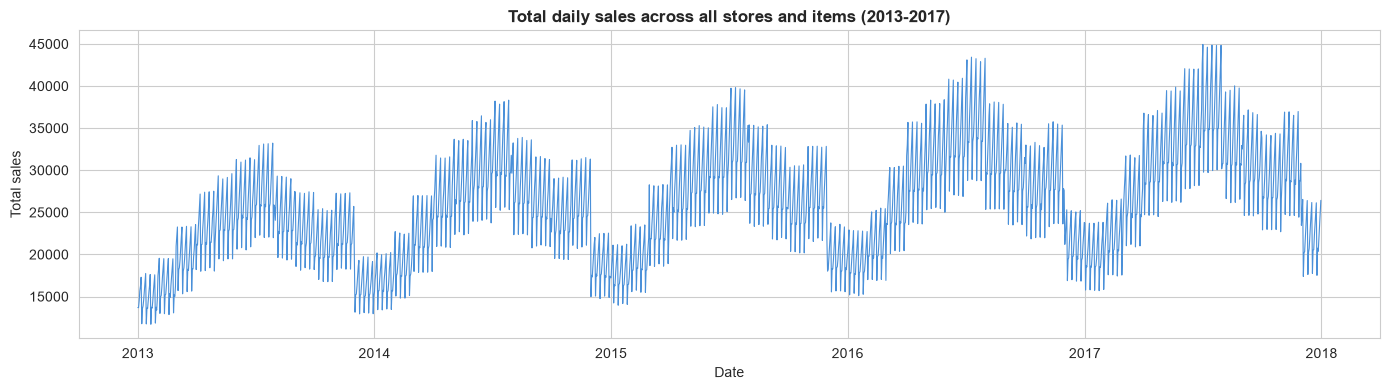

In [5]:
daily_sales = train.groupby('date')['sales'].sum().reset_index()

plt.figure(figsize=(14, 4))
plt.plot(daily_sales['date'], daily_sales['sales'], color='#4A90D9', linewidth=0.8)
plt.title('Total daily sales across all stores and items (2013-2017)', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total sales')
plt.tight_layout()
plt.show()

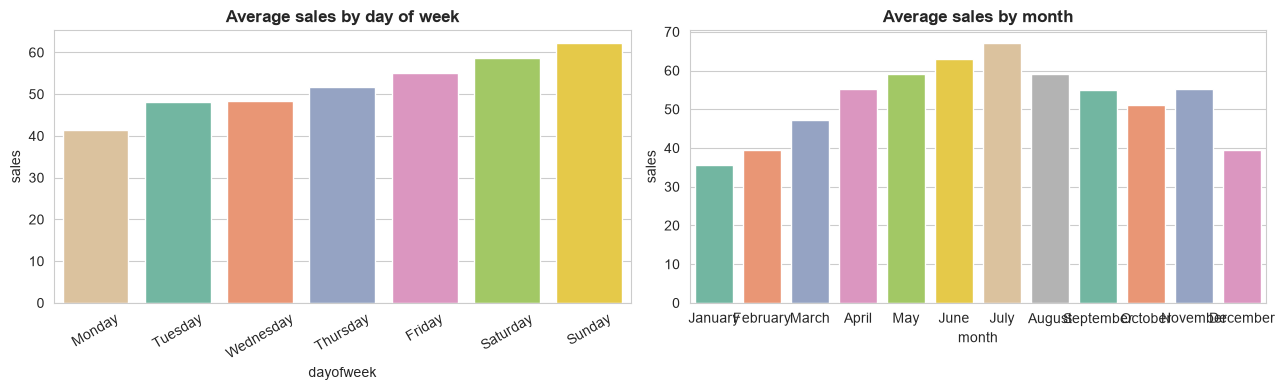

In [15]:
train['dayofweek'] = train['date'].dt.day_name()
train['month'] = train['date'].dt.month_name()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
month_order=[
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December",
]
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
sns.barplot(data=train, x='dayofweek', y='sales', order=dow_order, ax=axes[0],
            hue='dayofweek', palette='Set2', legend=False, errorbar=None)
axes[0].set_title('Average sales by day of week', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(data=train, x='month', y='sales', ax=axes[1],
            hue='month', palette='Set2', legend=False, errorbar=None,order=month_order,width=0.8)
axes[1].set_title('Average sales by month', fontweight='bold')

plt.tight_layout()
plt.show()

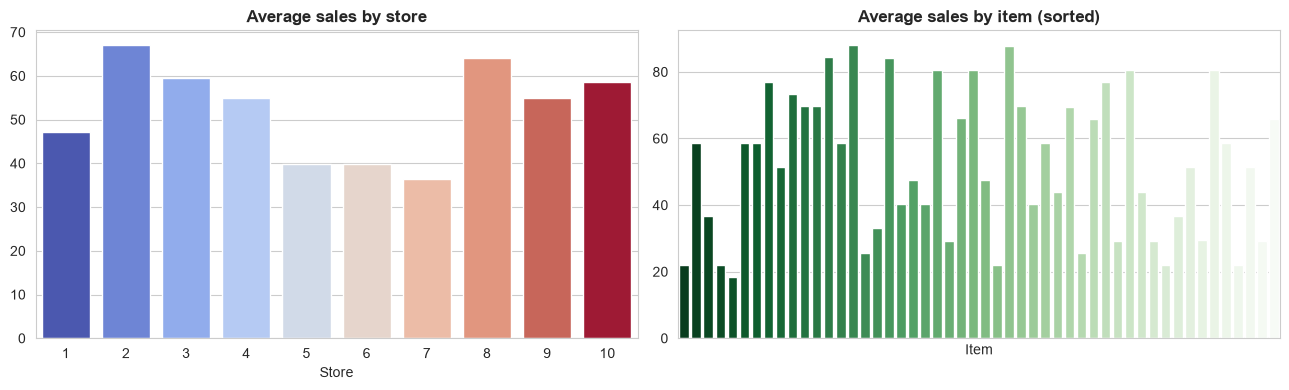

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

store_avg = train.groupby('store')['sales'].mean().sort_values(ascending=False)
sns.barplot(x=store_avg.index, y=store_avg.values, ax=axes[0],
            hue=store_avg.index, palette='coolwarm', legend=False)
axes[0].set_title('Average sales by store', fontweight='bold')
axes[0].set_xlabel('Store')

item_avg = train.groupby('item')['sales'].mean().sort_values(ascending=False)
sns.barplot(x=item_avg.index, y=item_avg.values, ax=axes[1],
            hue=item_avg.index, palette='Greens_r', legend=False)
axes[1].set_title('Average sales by item (sorted)', fontweight='bold')
axes[1].set_xlabel('Item')
axes[1].set_xticks([])  # 50 items — individual labels would be unreadable

plt.tight_layout()
plt.show()

In [28]:
train = train.sort_values(['store', 'item', 'date']).reset_index(drop=True)

# Calendar features
train['dayofweek_num'] = train['date'].dt.dayofweek
train['month'] = train['date'].dt.month
train['year'] = train['date'].dt.year
train['is_weekend'] = train['dayofweek_num'].apply(lambda x: 1 if x>=5 else 0)

# Lag features — sales N days ago, computed PER store-item combination
train['lag_7'] = train.groupby(['store', 'item'])['sales'].shift(7)
train['lag_28'] = train.groupby(['store', 'item'])['sales'].shift(28)

# Rolling averages — again, per store-item combination
train['rolling_mean_7'] = train.groupby(['store', 'item'])['sales'].shift(1).rolling(7).mean()
train['rolling_mean_30'] = train.groupby(['store', 'item'])['sales'].shift(1).rolling(30).mean()

print("Rows before dropping NaNs:", train.shape[0])
train = train.dropna().reset_index(drop=True)
print("Rows after dropping NaNs:", train.shape[0])

train.head(10)

Rows before dropping NaNs: 868000
Rows after dropping NaNs: 853000


,date,store,item,sales,dayofweek,month,dayofweek_num,year,is_weekend,lag_7,lag_28,rolling_mean_7,rolling_mean_30
0,2013-05-01,1,1,16,Wednesday,5,2,2013,0,13.0,24.0,16.285714,17.400000
1,2013-05-02,1,1,23,Thursday,5,3,2013,0,14.0,18.0,16.714286,17.566667
2,2013-05-03,1,1,22,Friday,5,4,2013,0,20.0,19.0,18.000000,17.700000
3,2013-05-04,1,1,20,Saturday,5,5,2013,1,22.0,23.0,18.285714,17.633333
4,2013-05-05,1,1,14,Sunday,5,6,2013,1,19.0,17.0,18.000000,17.700000
5,2013-05-06,1,1,14,Monday,5,0,2013,0,11.0,19.0,17.285714,17.533333
6,2013-05-07,1,1,15,Tuesday,5,1,2013,0,15.0,13.0,17.714286,17.233333
7,2013-05-08,1,1,14,Wednesday,5,2,2013,0,16.0,19.0,17.714286,17.166667
8,2013-05-09,1,1,11,Thursday,5,3,2013,0,23.0,16.0,17.428571,17.000000
9,2013-05-10,1,1,16,Friday,5,4,2013,0,22.0,18.0,15.714286,16.933333


In [29]:
split_date = '2017-01-01'

train_set = train[train['date'] < split_date]
val_set = train[train['date'] >= split_date]

print("Train:", train_set.shape, "| Date range:", train_set['date'].min(), "to", train_set['date'].max())
print("Validation:", val_set.shape, "| Date range:", val_set['date'].min(), "to", val_set['date'].max())

feature_cols = ['store', 'item', 'dayofweek_num', 'month', 'year', 'is_weekend',
                'lag_7', 'lag_28', 'rolling_mean_7', 'rolling_mean_30']

X_train = train_set[feature_cols]
y_train = train_set['sales']
X_val = val_set[feature_cols]
y_val = val_set['sales']

Train: (670500, 13) | Date range: 2013-05-01 00:00:00 to 2016-12-31 00:00:00
Validation: (182500, 13) | Date range: 2017-01-01 00:00:00 to 2017-12-31 00:00:00


In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Linear Regression baseline
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_val)

# Random Forest
rf = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_val)

# Evaluate both
for name, preds in [("Linear Regression", lr_preds), ("Random Forest", rf_preds)]:
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    mae = mean_absolute_error(y_val, preds)
    print(f"{name} — RMSE: {rmse:.3f} | MAE: {mae:.3f}")

Linear Regression — RMSE: 9.141 | MAE: 6.996
Random Forest — RMSE: 8.308 | MAE: 6.370


In [31]:
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Scale features — ANNs are sensitive to feature scale, unlike tree-based models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

ann = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1)   # <- no activation function: this is regression, not classification
])

ann.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

history = ann.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

ann_preds = ann.predict(X_val_scaled).ravel()
rmse = np.sqrt(mean_squared_error(y_val, ann_preds))
mae = mean_absolute_error(y_val, ann_preds)
print(f"ANN — RMSE: {rmse:.3f} | MAE: {mae:.3f}")

d:\machine-learning-part1\1- Machine Learning A-Z\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 247.1194 - mae: 10.7394 - val_loss: 78.1855 - val_mae: 6.7942
Epoch 2/50
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 133.2700 - mae: 8.5868 - val_loss: 76.5964 - val_mae: 6.6756
Epoch 3/50
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 128.1555 - mae: 8.3927 - val_loss: 77.6959 - val_mae: 6.7262
Epoch 4/50
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 123.6893 - mae: 8.2407 - val_loss: 82.3702 - val_mae: 6.8825
Epoch 5/50
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 119.4080 - mae: 8.0983 - val_loss: 75.8741 - val_mae: 6.6532
Epoch 6/50
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 115.8124 - mae: 7.9727 - val_loss: 77.9976 - val_mae: 6.7452
Epoch 7/50
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 112.4651 - mae: 7.8635 - val_loss: 81.2347 - val_mae: 6.8451
Epoch 8/50
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 109.6695 - mae: 7.7630 - val_loss: 76.9485 - val_mae: 6.6993
Epoch 9/50
2620

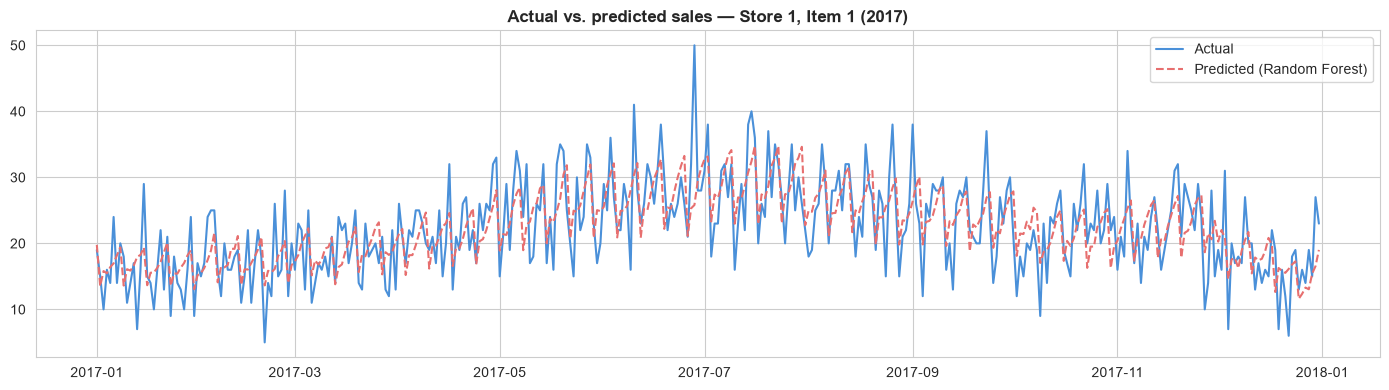

In [33]:
val_plot = val_set.copy()
val_plot['rf_pred'] = rf_preds

sample = val_plot[(val_plot['store'] == 1) & (val_plot['item'] == 1)].sort_values('date')

plt.figure(figsize=(14, 4))
plt.plot(sample['date'], sample['sales'], label='Actual', color='#4A90D9', linewidth=1.5)
plt.plot(sample['date'], sample['rf_pred'], label='Predicted (Random Forest)', color='#E76F6F', linewidth=1.5, linestyle='--')
plt.title('Actual vs. predicted sales — Store 1, Item 1 (2017)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'ANN'],
    'RMSE': [
        np.sqrt(mean_squared_error(y_val, lr_preds)),
        np.sqrt(mean_squared_error(y_val, rf_preds)),
        np.sqrt(mean_squared_error(y_val, ann_preds)),
    ],
    'MAE': [
        mean_absolute_error(y_val, lr_preds),
        mean_absolute_error(y_val, rf_preds),
        mean_absolute_error(y_val, ann_preds),
    ],
})
comparison = comparison.round(3).sort_values('RMSE')
comparison

,Model,RMSE,MAE
1,Random Forest,8.308,6.370
2,ANN,8.711,6.653
0,Linear Regression,9.141,6.996
